In [ ]:
!pip install lightgbm

In [1]:
# 📦 Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

Context:
It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

Content:
The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

- Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Why?

In imbalanced datasets, especially when the positive class (e.g., fraud detection, disease presence) is much rarer than the negative class (e.g., non-fraud, healthy individuals), accuracy becomes misleading. Here's why:

1. Accuracy Formula:
Accuracy = (TP+TN)/Total_Samples

In an imbalanced dataset, where the negative class is much larger than the positive class, a model can simply predict the majority class (negative class) most of the time and still achieve a high accuracy score. For instance, in a dataset with 95% negatives and 5% positives, even if your model predicts every instance as negative, you'd still get an accuracy of 95%, despite failing to identify a single positive class instance.

2. Precision-Recall (PR) Curve:

The Precision-Recall Curve focuses on the performance of a model concerning the positive class (the minority class in imbalanced datasets).

Precision is the ratio of correct positive predictions to total positive predictions (how many predicted positives were actually correct).

Recall (or Sensitivity) is the ratio of correct positive predictions to total actual positives (how many actual positives were correctly predicted).

AUPRC (Area Under the Precision-Recall Curve) is a better evaluation metric for imbalanced classification because it directly reflects how well the model is identifying the positive class, which is typically more important in cases like fraud detection, disease prediction, etc.

3. AUPRC is sensitive to the positive class performance. It helps to evaluate the trade-off between precision and recall at different thresholds, which gives a more accurate picture of how well the model is distinguishing between the minority (positive) and majority (negative) classes.

- Confusion matrix accuracy is not meaningful for unbalanced classification. Why?

In imbalanced classification problems, the Confusion Matrix itself is not inherently problematic, but accuracy derived from it can be misleading:

1. Imbalanced Classifications:

For example, if you have a dataset where 95% of the samples are from the majority class (say, "No Fraud") and only 5% are from the minority class (say, "Fraud"), the model could easily predict "No Fraud" for most samples and still get a high accuracy.

Confusion Matrix for an imbalanced dataset:

True Negatives (TN): Correctly predicting the majority class.

False Positives (FP): Incorrectly predicting the minority class as the majority.

False Negatives (FN): Missing the minority class (predicting it as the majority class).

True Positives (TP): Correctly predicting the minority class.

Accuracy would give:
Accuracy = (TP+TN)/(TP+TN+FP+FN)

But, in an imbalanced dataset, if the model predicts almost everything as the majority class (TN), it could still achieve high accuracy, even if it is not identifying any of the minority class (fraud detection, for instance).

2. Confusion Matrix Metrics:

The more informative metrics to consider from the confusion matrix in imbalanced data are Precision, Recall, F1-Score, and AUC.

Precision and Recall help you understand the trade-off between false positives and false negatives, which is more relevant in imbalanced problems.

F1-Score combines Precision and Recall into a single measure to give the harmonic mean of the two.

AUC-ROC or AUC-PR are also better measures in class-imbalanced problems since they provide a more holistic view of the classifier’s performance across various thresholds.

- SUMMARY:
  
AUPRC is preferred over accuracy for imbalanced classification problems because it focuses on the minority (positive) class performance, which is often the most important in real-world problems (like fraud detection, medical diagnoses, etc.).

Confusion Matrix accuracy in imbalanced datasets is misleading because a model can achieve high accuracy by simply predicting the majority class, missing the minority class entirely. Instead, precision, recall, F1-score, or AUPRC should be used to get a more accurate measure of model performance.

Let's clarify the difference between AUC and ROC-AUC:

1. AUC (Area Under the Curve)
Definition: AUC stands for Area Under the Curve, and it generally refers to the area under a curve plotted for any classification model's performance.

AUC can be used in various contexts, but in classification, the most common AUC is the Area Under the ROC Curve (which we call ROC-AUC).

The AUC score itself is a single scalar value between 0 and 1 that measures the overall performance of a classifier.

Interpretation:

AUC = 1 means perfect classification (the model has no error).

AUC = 0.5 means the model performs no better than random guessing.

AUC < 0.5 means the model performs worse than random guessing (which could indicate that the model is predicting the wrong class most of the time).

2. ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)
Definition: ROC-AUC refers to the Area Under the ROC Curve, where ROC stands for Receiver Operating Characteristic.

The ROC curve is a graphical representation of the trade-off between the True Positive Rate (TPR) and False Positive Rate (FPR) at various classification thresholds.

True Positive Rate (TPR), also known as Recall or Sensitivity, is calculated as:

TPR=TP/(TP+FN)

FPR=FP/(FP+TN)

The ROC curve plots TPR (y-axis) against FPR (x-axis) at various threshold values, and the area under this curve is ROC-AUC.

ROC-AUC Interpretation: Similar to AUC:

AUC = 1 means perfect classifier (perfectly distinguishes between positive and negative classes).

AUC = 0.5 means the model's predictions are no better than random guessing.

AUC < 0.5 indicates that the model is worse than random guessing.

- Key Points of Difference:

AUC is a general term used to describe the area under any curve used for evaluation. In classification, it is almost always used to refer to ROC-AUC unless specified otherwise.

ROC-AUC specifically refers to the Area Under the ROC Curve, which evaluates how well the classifier distinguishes between the positive and negative classes over a range of thresholds.

ROC-AUC is the most common use of AUC in classification tasks, particularly for binary classification.

AUC (or ROC-AUC) is a metric that combines both sensitivity (true positive rate) and specificity (false positive rate) to give an overall sense of how well the model performs in separating the two classes.

- Summary:
AUC generally refers to the area under any classification curve (though typically ROC-AUC in binary classification).

ROC-AUC is the area under the ROC curve specifically, which is calculated based on different threshold values for classification.

Thus, in the context of binary classification, AUC and ROC-AUC are typically used interchangeably, with ROC-AUC being the more specific term.

In [3]:
# 🔽 Load the dataset
data = pd.read_csv('creditcard.csv')

In [5]:
# 👀 Quick look
print(data.head())
print(data['Class'].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [9]:
# 🧹 Preprocessing
# The dataset is already scaled for all features except 'Time' and 'Amount'
# We'll scale 'Amount'
from sklearn.preprocessing import StandardScaler
data['Amount'] = StandardScaler().fit_transform(data[['Amount']])
data = data.drop(['Time'], axis=1)

The StandardScaler is a feature scaling technique in machine learning that standardizes the features of your dataset, transforming them to have a mean of 0 and a standard deviation of 1. This process is also known as z-score normalization.

In [11]:
# 🧪 Train/Test Split
X = data.drop('Class', axis=1)
y = data['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

The parameter stratify=y ensures that the split between training and testing datasets preserves the same proportion of classes as in the original dataset (for the target variable y).

- Explanation of stratify in train_test_split:

stratify=y: By specifying stratify=y, you're telling the function to maintain the same distribution of the target variable (usually the class labels) in both the training and test datasets as it is in the original dataset.

This is particularly important in imbalanced classification tasks, where one class (e.g., fraudulent transactions or disease presence) might be underrepresented compared to the other class (e.g., non-fraudulent transactions or healthy individuals). Without stratification, the random split could result in the training or test set having disproportionately few examples of the minority class, which could affect the model's ability to learn from that class.

Example:
If the original dataset has 80% of class 0 (non-fraud) and 20% of class 1 (fraud), using stratify=y will make sure that both the training and test sets have approximately 80% of class 0 and 20% of class 1.

- Why is Stratification Important?
  
In datasets with class imbalance (e.g., fraud detection, disease prediction), a random split without stratification could create training and test sets that are not representative of the overall class distribution, leading to:

Model bias towards the majority class.

Poor performance on the minority class.

Unreliable evaluation metrics (e.g., F1-score, AUC) due to the imbalance in the test set.

Stratification makes sure both training and testing sets have a balanced representation of each class, ensuring the model has a fair chance to learn and evaluate across all classes.

- In summary:
stratify=y ensures that the train-test split maintains the same class distribution as the original dataset, which is particularly useful for imbalanced datasets.

In [16]:
# 🌱 Train LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

The reference parameter in the lgb.Dataset constructor is used to define the relationship between the test dataset and the training dataset for LightGBM. Specifically, it is used when creating a validation set to ensure that the test data is evaluated in the same way as the training data.

Explanation of the reference parameter:
When training a model using LightGBM, you might want to use the test or validation dataset to monitor the model's performance during training. LightGBM supports early stopping and monitoring the performance on the validation set. To properly compare the test or validation dataset with the training dataset, it is necessary to provide a reference dataset.

The reference parameter is set to the training data (train_data) to ensure that both the training and testing datasets are handled similarly during model evaluation, particularly in terms of the feature types and categorical feature handling.

Purpose of the reference parameter:
It ensures consistency in feature handling, including:

Categorical features: If your training dataset contains categorical features, the test or validation dataset should have the same categorical feature handling.

Feature names and dtypes: It ensures that the test set has the same features and their corresponding data types as the training set, avoiding errors during model evaluation.

How it works:

Training: You create a Dataset object for the training data.

Validation/Test: You create another Dataset object for the validation/test data, and you pass the training data as the reference to ensure that both datasets share the same settings.

In [61]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    valid_sets=(test_data),
    #early_stopping_rounds=10,
    #verbose_eval=10
)

In LightGBM, verbose=-1 is used to suppress all output/logging messages during training — especially the ones printed during each boosting iteration.

What does verbose control in LightGBM?
The verbose parameter controls the amount of logging LightGBM prints out while training:

verbose value	and  Effect:

- -1	Silences all messages (no output at all)
- 0	Only critical warnings/errors are shown
- 1 or greater	Shows detailed training logs, like loss, metrics per iteration, etc.

In [65]:
# 🔍 Predict & Evaluate
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[56802    62]
 [   24    74]]


In [67]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.54      0.76      0.63        98

    accuracy                           1.00     56962
   macro avg       0.77      0.88      0.82     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9048220494585004


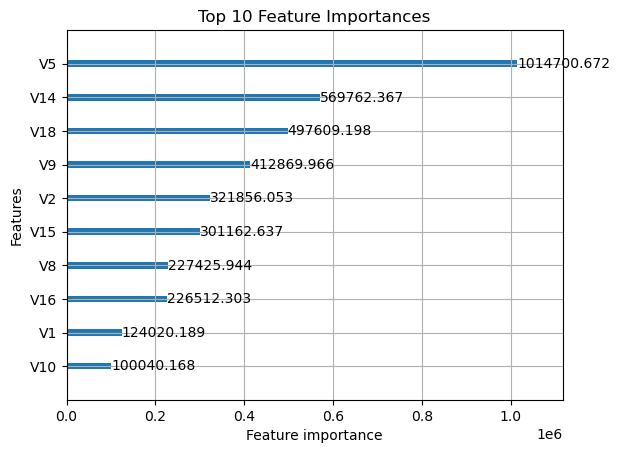

In [69]:
# 📊 Feature Importance
lgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.title("Top 10 Feature Importances")
plt.show()